In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

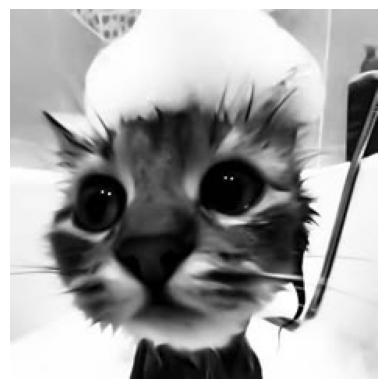

In [2]:
image = cv2.imread('mykitty.jpg', cv2.IMREAD_GRAYSCALE)

plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()

In [ ]:
hist = cv2.calcHist([image], [0], None, [256], [0, 256])

hist = hist.flatten()


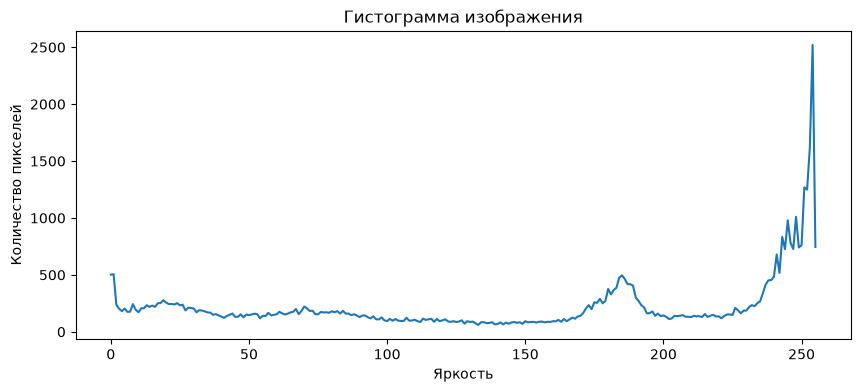

In [4]:
plt.figure(figsize=(10, 4))
plt.plot(hist)
plt.xlabel('Яркость')
plt.ylabel('Количество пикселей')
plt.title('Гистограмма изображения')
plt.show()


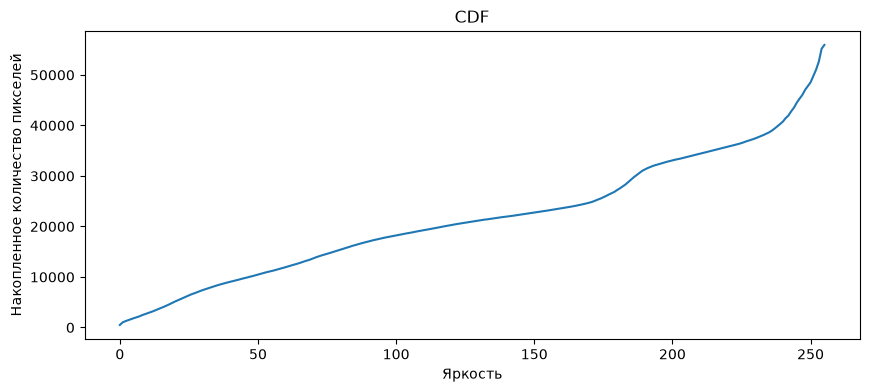

In [ ]:
cdf = hist.cumsum()

plt.figure(figsize=(10, 4))
plt.plot(cdf)
plt.xlabel('Яркость')
plt.ylabel('Накопленное количество пикселей')
plt.title('CDF')
plt.show()


In [ ]:
equalized_image = cv2.equalizeHist(image)


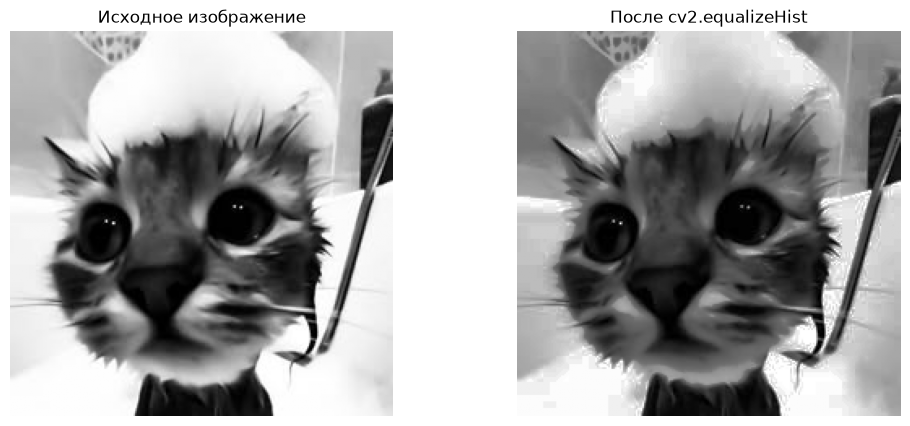

In [7]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(equalized_image, cmap='gray')
plt.title('После cv2.equalizeHist')
plt.axis('off')

plt.show()


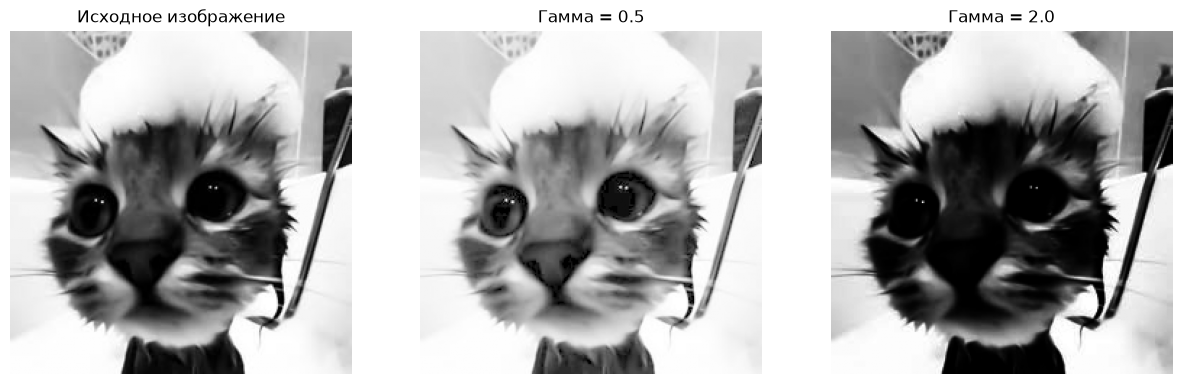

In [8]:
gamma1 = 0.5
gamma2 = 2.0

gamma_image1 = np.array(
    255 * (image / 255) ** gamma1,
    dtype=np.uint8
)

gamma_image2 = np.array(
    255 * (image / 255) ** gamma2,
    dtype=np.uint8
)


plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(gamma_image1, cmap='gray')
plt.title('Гамма = 0.5')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(gamma_image2, cmap='gray')
plt.title('Гамма = 2.0')
plt.axis('off')

plt.show()

In [9]:
from skimage.metrics import structural_similarity, mean_squared_error

mse_gamma1 = mean_squared_error(image, gamma_image1)
ssim_gamma1 = structural_similarity(image, gamma_image1)

mse_gamma2 = mean_squared_error(image, gamma_image2)
ssim_gamma2 = structural_similarity(image, gamma_image2)

print("Gamma = 0.5")
print("MSE:", mse_gamma1)
print("SSIM:", ssim_gamma1)

print("\nGamma = 2.0")
print("MSE:", mse_gamma2)
print("SSIM:", ssim_gamma2)

Gamma = 0.5
MSE: 1454.5662947865264
SSIM: 0.8511338322602565

Gamma = 2.0
MSE: 1446.3925480941143
SSIM: 0.744004492082737


In [10]:
mean = image.mean()
std = image.std()

print("Среднее значение:", mean)
print("Стандартное отклонение:", std)

Среднее значение: 156.23451691339483
Стандартное отклонение: 87.35159632766904


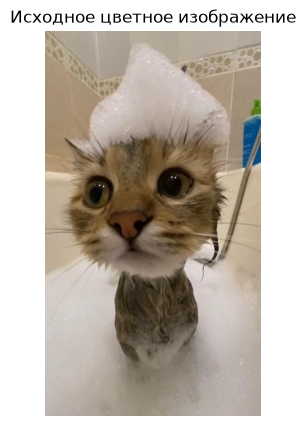

In [11]:
color_image = cv2.imread('mykittycolor.jpg')

color_image = cv2.cvtColor(color_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 5))
plt.imshow(color_image)
plt.title('Исходное цветное изображение')
plt.axis('off')
plt.show()

In [12]:
mean_src = image.mean()
std_src = image.std()

eq_gray = equalized_image

mean_eq = eq_gray.mean()
std_eq = eq_gray.std()

print('Статистика исходного изображения:')
print('Mean:', mean_src)
print('Std:', std_src)

print('\nСтатистика eq_gray:')
print('Mean:', mean_eq)
print('Std:', std_eq)


Статистика исходного изображения:
Mean: 156.23451691339483
Std: 87.35159632766904

Статистика eq_gray:
Mean: 127.49358149181148
Std: 75.21983380717413


In [ ]:

corrected_color = color_image.astype(np.float32)

corrected_color = (corrected_color - mean_src) / std_src
corrected_color = corrected_color * std_eq + mean_eq

corrected_color = np.clip(corrected_color, 0, 255).astype(np.uint8)

print('Статистика после цветокоррекции:')
print('Mean:', corrected_color.mean())
print('Std:', corrected_color.std())



Статистика после цветокоррекции:
Mean: 114.922696941992
Std: 44.874126859624226


In [14]:

print("Статистическая цветокоррекция выполнена")


Статистическая цветокоррекция выполнена


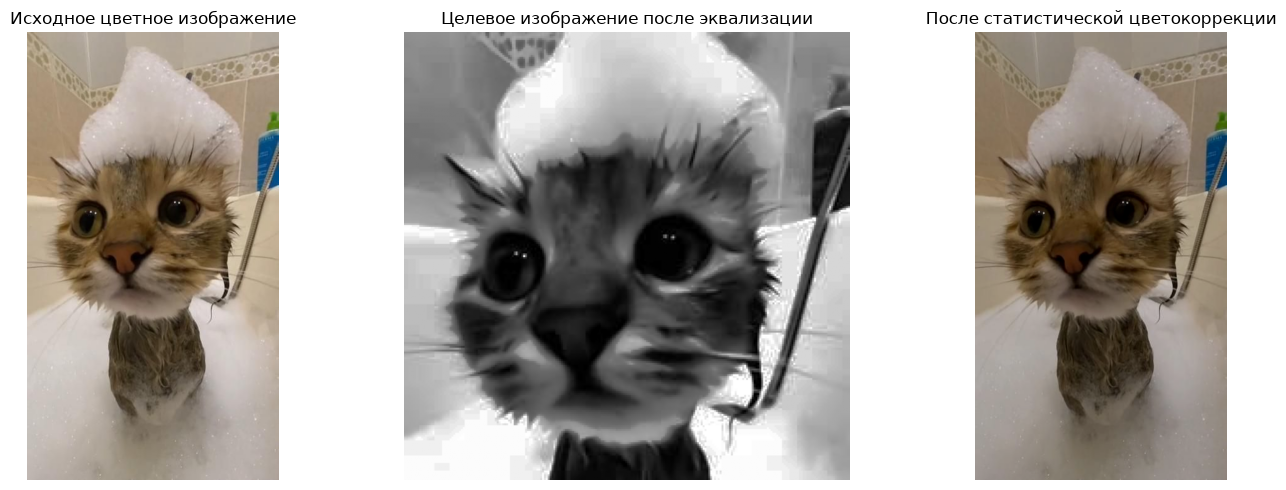

In [15]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(color_image)
plt.title('Исходное цветное изображение')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(eq_gray, cmap='gray')
plt.title('Целевое изображение после эквализации')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(corrected_color)
plt.title('После статистической цветокоррекции')
plt.axis('off')

plt.tight_layout()
plt.show()


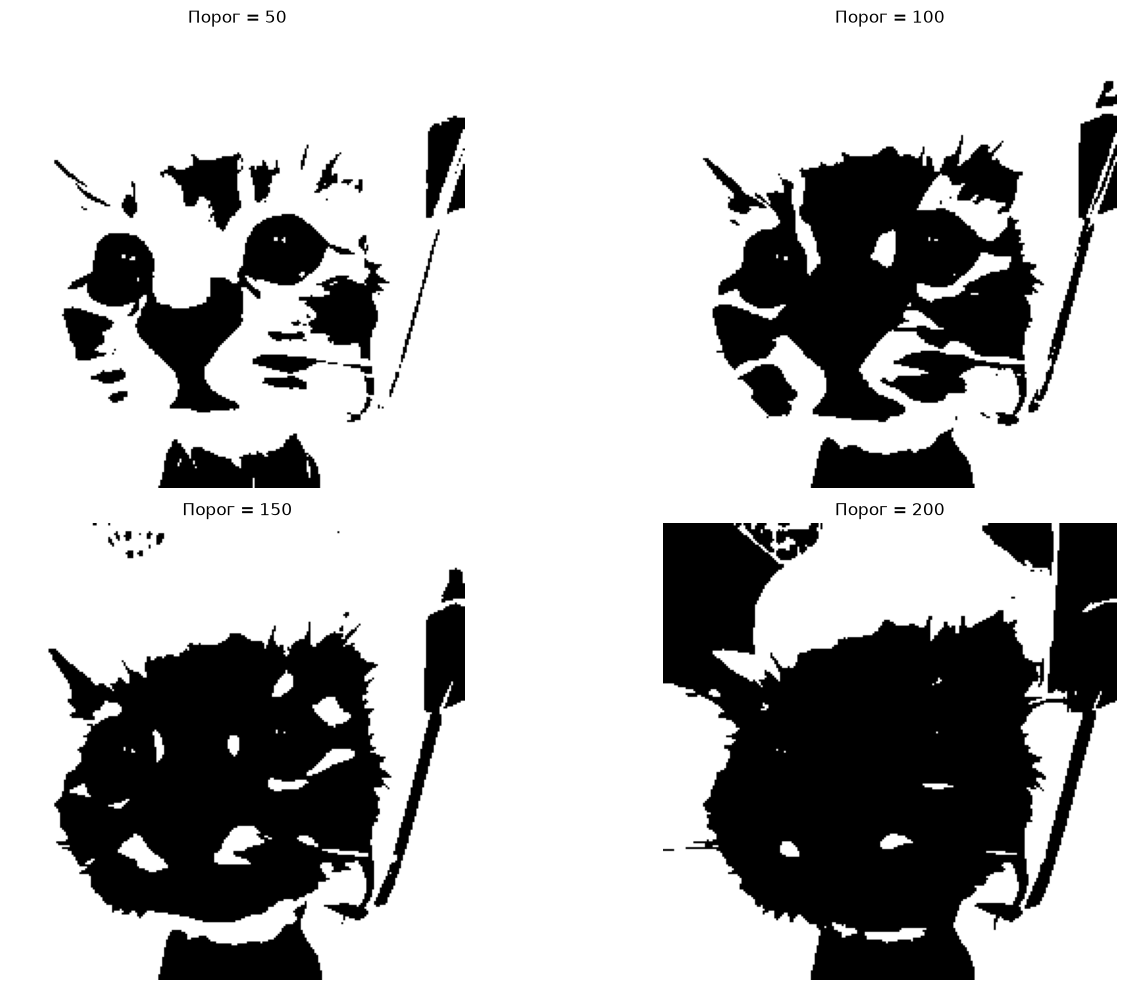

In [16]:
thresholds = [50, 100, 150, 200]

plt.figure(figsize=(15, 10))

for i, threshold in enumerate(thresholds):
    
    _, binary = cv2.threshold(
        image,
        threshold,
        255,
        cv2.THRESH_BINARY
    )
    
    plt.subplot(2, 2, i + 1)
    plt.imshow(binary, cmap='gray')
    plt.title(f'Порог = {threshold}')
    plt.axis('off')

plt.tight_layout()
plt.show()